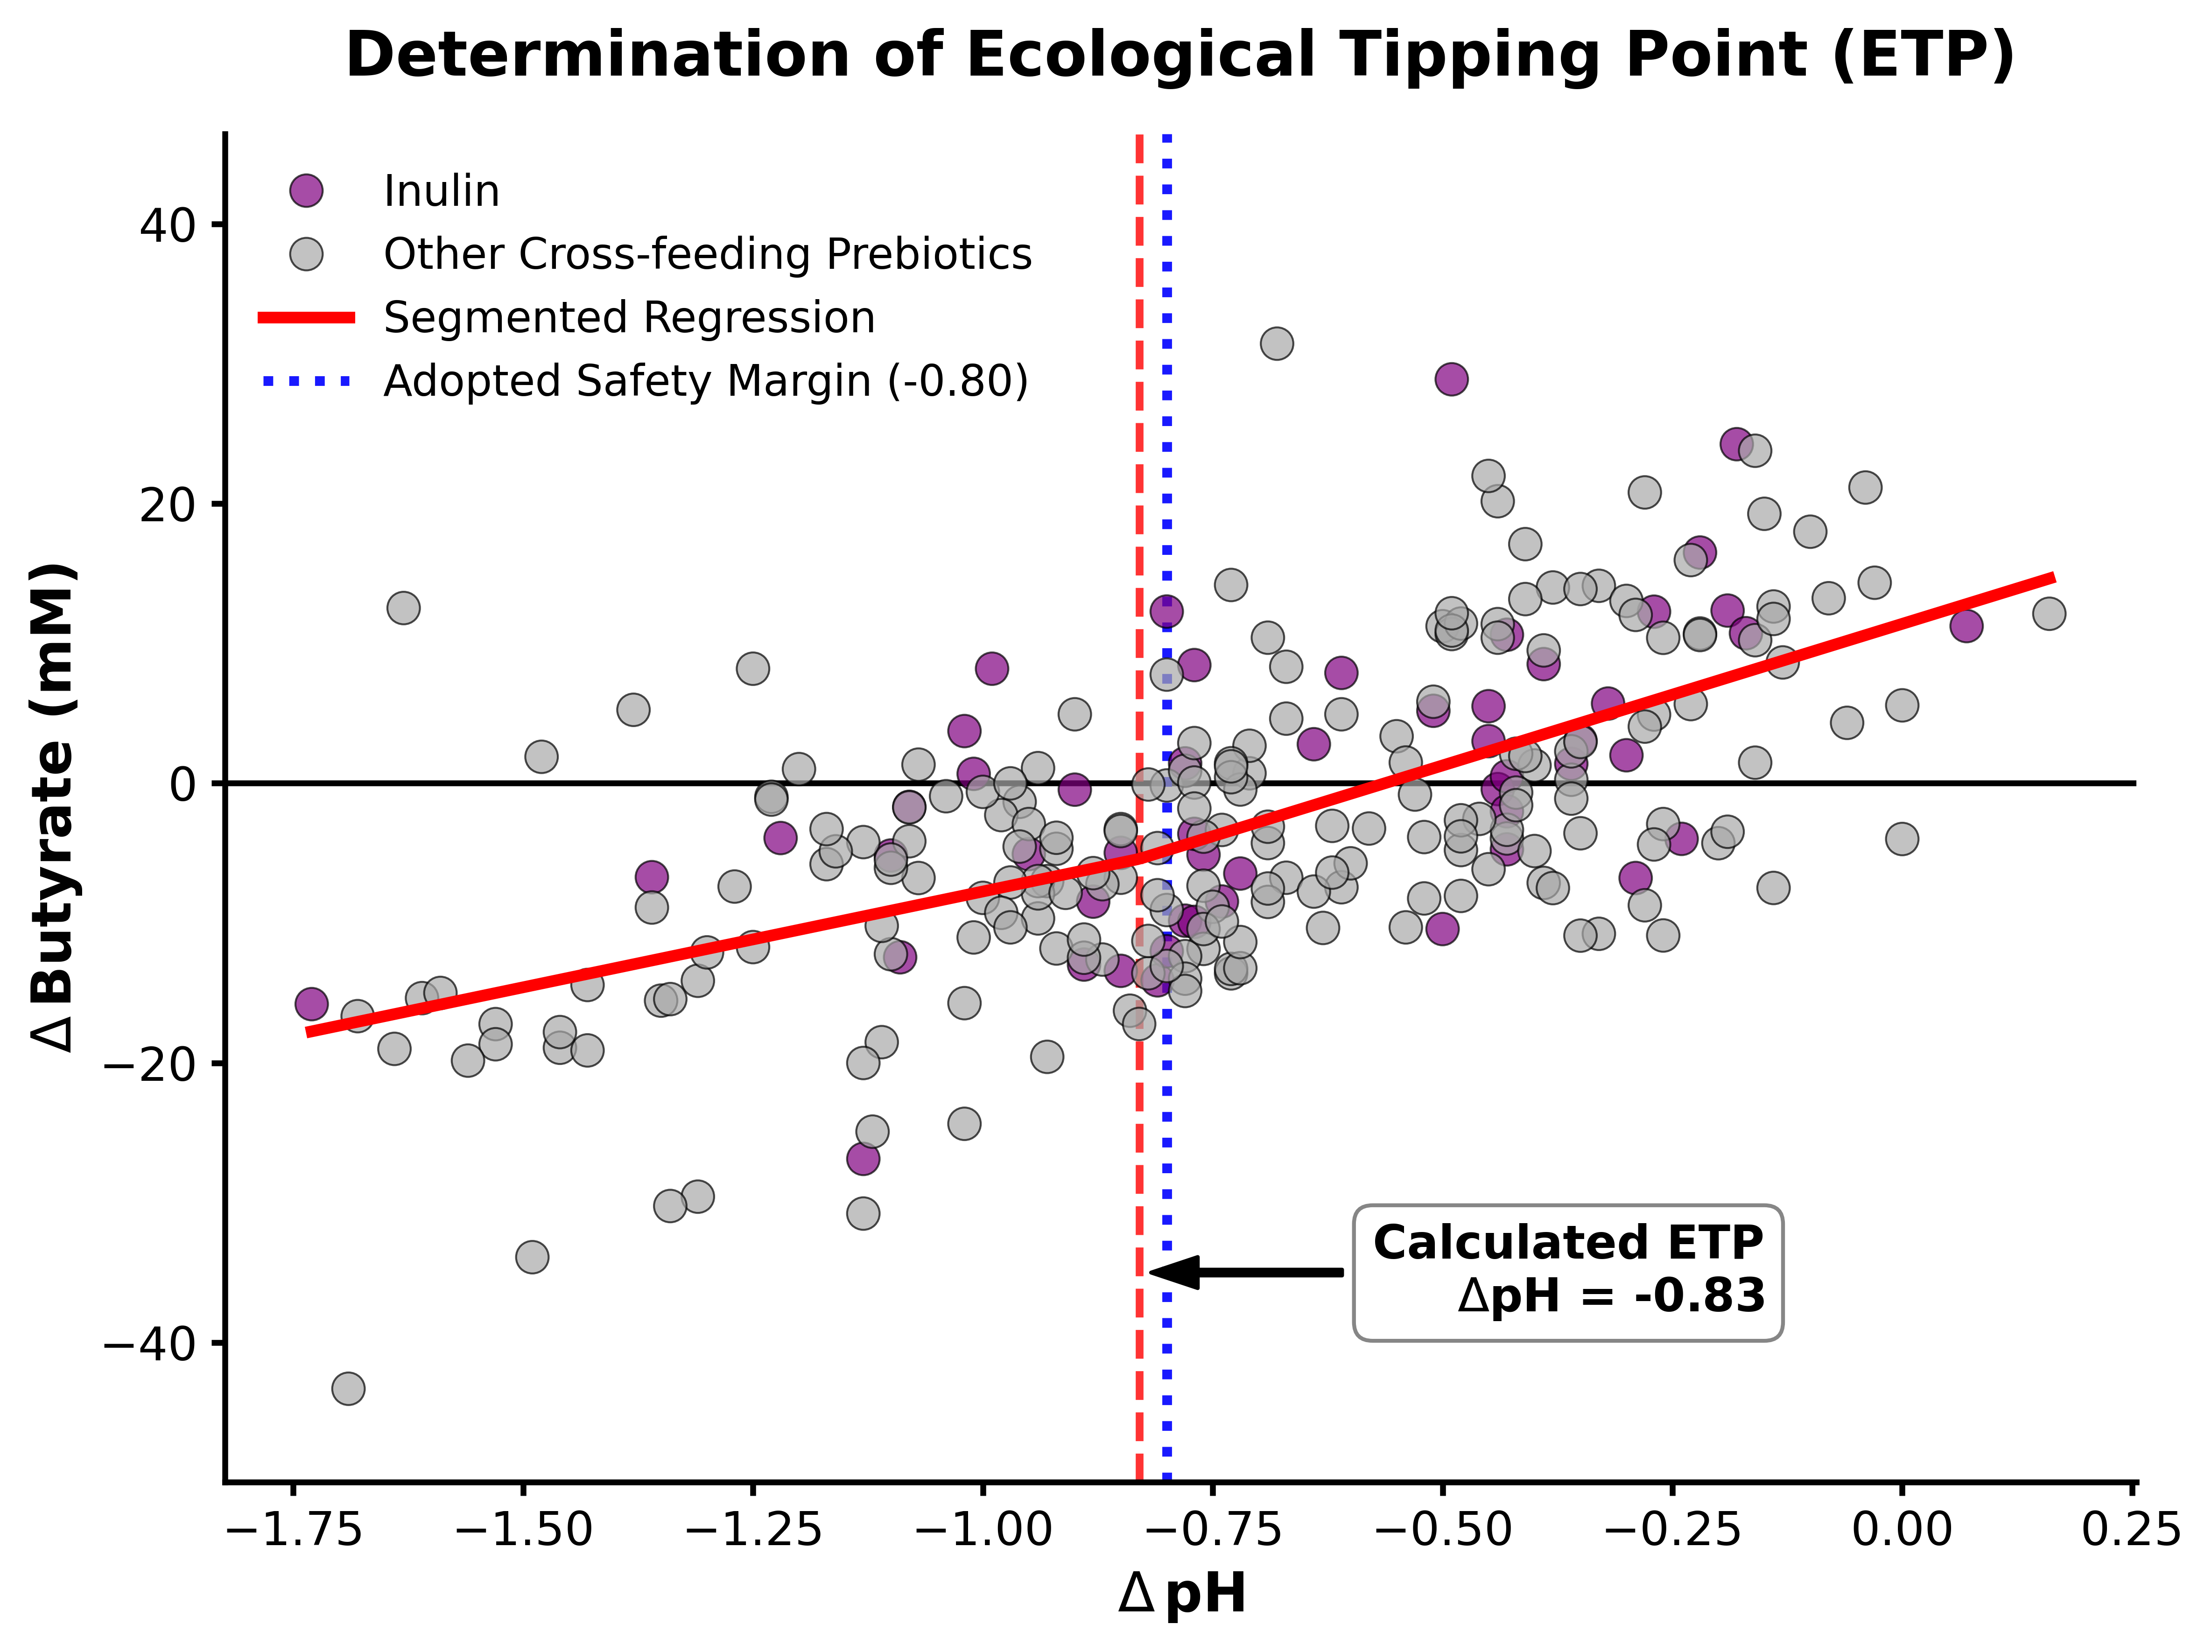

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import warnings

warnings.filterwarnings('ignore')

# =============================================================================
# 1. Publication-Quality Visualization Settings
# =============================================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5

DPI_SETTING = 600

# =============================================================================
# 2. Data Loading & Preprocessing
# =============================================================================
df_ph = pd.read_csv('pH.csv')
df_buty = pd.read_csv('Butyrate(mM).csv')
donors = [c for c in df_ph.columns if c.startswith('HS-')]

def get_raw_data(df, name):
    mask = df['KULFFI'].str.strip() == name
    if not mask.any(): return pd.Series(index=donors, dtype=float)
    s = df[mask][donors].iloc[0]
    s = s.astype(str).replace(['Undetermined', '-', 'nan', '#VALUE!'], np.nan)
    return pd.to_numeric(s, errors='coerce')

ctrl_ph = get_raw_data(df_ph, 'Control')
ctrl_buty = get_raw_data(df_buty, 'Control')

# 5 Validated Cross-feeding Prebiotics
target_ids = ['Inulin', 'KULFFI-14', 'KULFFI-15', 'KULFFI-9', 'KULFFI-17']

dfs = []
for mat in target_ids:
    d_ph = get_raw_data(df_ph, mat) - ctrl_ph
    d_buty = get_raw_data(df_buty, mat) - ctrl_buty

    label_name = 'Inulin' if mat == 'Inulin' else 'Other Cross-feeding Prebiotics'

    temp = pd.DataFrame({
        'Delta_pH': d_ph,
        'Delta_Butyrate': d_buty,
        'Substrate': label_name
    }).dropna()
    dfs.append(temp)

df_model = pd.concat(dfs, ignore_index=True)

# =============================================================================
# 3. Segmented Regression (Grid Search for Global Minimum)
# =============================================================================
def piecewise_linear(x, x0, y0, k1, k2):
    return np.where(x < x0, k1*(x-x0) + y0, k2*(x-x0) + y0)

best_ssr = np.inf
best_popt = None

for g in np.linspace(-1.5, -0.1, 100):
    p_guess = [g, 0, 10, 20]
    try:
        popt, _ = curve_fit(piecewise_linear, df_model['Delta_pH'], df_model['Delta_Butyrate'], p0=p_guess, maxfev=10000)
        y_pred = piecewise_linear(df_model['Delta_pH'], *popt)
        ssr = np.sum((df_model['Delta_Butyrate'] - y_pred)**2)
        if ssr < best_ssr:
            best_ssr = ssr
            best_popt = popt
    except:
        continue

etp_val = best_popt[0]

# =============================================================================
# 4. Figure Generation
# =============================================================================
fig, ax = plt.subplots(figsize=(8, 6), dpi=DPI_SETTING)

palette = {'Inulin': '#800080', 'Other Cross-feeding Prebiotics': '#a9a9a9'}

sns.scatterplot(data=df_model, x='Delta_pH', y='Delta_Butyrate', hue='Substrate',
                palette=palette, s=70, edgecolor='black', linewidth=0.5, alpha=0.7, zorder=2, ax=ax)

x_line = np.linspace(df_model['Delta_pH'].min(), df_model['Delta_pH'].max(), 300)
y_line = piecewise_linear(x_line, *best_popt)
ax.plot(x_line, y_line, color='red', linewidth=3, zorder=4, label='Segmented Regression')

ax.axvline(etp_val, color='red', linestyle='--', linewidth=2, alpha=0.8, zorder=1)
ax.axhline(0, color='black', linestyle='-', linewidth=1.5, zorder=0)

ax.axvline(-0.80, color='blue', linestyle=':', linewidth=2.5, alpha=0.9, zorder=1, label='Adopted Safety Margin (-0.80)')

ax.set_title('Determination of Ecological Tipping Point (ETP)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel(r'$\Delta\,$pH', fontsize=14, fontweight='bold')
ax.set_ylabel(r'$\Delta\,$Butyrate (mM)', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', labelsize=12)

# Ensure the Y-axis has enough negative space to hold the annotation without overlapping plots
max_y = df_model['Delta_Butyrate'].max() + 15
ax.set_ylim(-50, max_y)

# =============================================================================
# Exact Annotation Placement (Lower Right, Straight Arrow)
# =============================================================================
# Placed exactly in the empty space at Y=-35, X=-0.15.
# Arrow is a perfectly straight horizontal line pointing to the ETP threshold.
ax.annotate(f'Calculated ETP\n$\Delta$pH = {etp_val:.2f}',
            xy=(etp_val, -35), xytext=(-0.15, -35),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
            fontsize=12, fontweight='bold', ha='right', va='center',
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.95))

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, frameon=False, loc='upper left', fontsize=11)

sns.despine(trim=False)
plt.tight_layout()
output_file = 'Supplementary_Figure_ETP.pdf'
plt.savefig(output_file, dpi=DPI_SETTING, bbox_inches='tight')